In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from statannotations.Annotator import Annotator

from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from skbio.stats.composition import clr, multi_replace
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import braycurtis, pdist, squareform

import scripts.TCR_utils as utils

import os
from itertools import combinations

In [2]:
metadata_path = "../data/metadata_with_ifn_predictions.csv"
results_path = "../../results/results_mixcr"

metadata = pd.read_csv(metadata_path)

# V, D and J segment gene usage of TCR beta chain

This notebook presents the results of TCR repertoire analysis we managed to achieve for beta chain of T-cell receptors. For all genes count matrices were obtained and transformed to frequency matrices. After that frequency distributions and medians were compared between sample groups using perMANOVA and pairwise Mann-Whitney criterion. Central log transformation was used in order to account for compositional natural of frequency data.

For V-segment genes we managed to achieve the reduction of batch-effect after generating frequency matrices. This implies that frequencies can be used for analysing V, D and J-segment gene usage across different datasets.

## V-segment gene usage analysis

First of all, we generated a TRBV-gene count matrix from the data that was output by MiXCR tool.

In [3]:
v_count_matrix = utils.get_gene_count_matrix(
    gene = "TRB",
    segment = "V",
    results_dir = results_path,
    metadata = metadata
).T

v_gene_cols = v_count_matrix.columns
v_count_matrix.head()

gene,TRBV1,TRBV10-1,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-1,TRBV12-2,TRBV12-3,...,TRBV7-1,TRBV7-2,TRBV7-3,TRBV7-4,TRBV7-5,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9
srr,,,,,,,,,,,,,,,,,,,,,
SRR10342368,0.0,0.0,2.0,4.0,4.0,9.0,1.0,0.0,0.0,19.0,...,0.0,7.0,3.0,0.0,0.0,3.0,1.0,3.0,6.0,3.0
SRR10342369,0.0,26.0,15.0,30.0,7.0,39.0,20.0,1.0,0.0,142.0,...,1.0,71.0,26.0,0.0,0.0,11.0,1.0,57.0,100.0,140.0
SRR10342370,1.0,2.0,8.0,44.0,19.0,43.0,8.0,0.0,0.0,98.0,...,0.0,95.0,29.0,3.0,0.0,13.0,5.0,16.0,90.0,46.0
SRR10342371,1.0,0.0,20.0,28.0,15.0,25.0,9.0,1.0,1.0,57.0,...,2.0,112.0,16.0,3.0,0.0,12.0,7.0,30.0,71.0,28.0
SRR12794681,0.0,2.0,4.0,7.0,4.0,21.0,1.0,0.0,0.0,28.0,...,0.0,16.0,7.0,0.0,0.0,10.0,11.0,1.0,41.0,10.0


### PCA for batch-effect visualisation

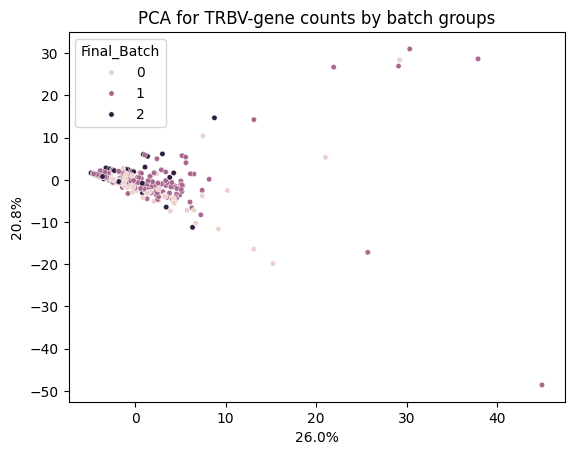

In [4]:
SRRs = v_count_matrix.index

scaler = RobustScaler()
scaled_cm = pd.DataFrame(scaler.fit_transform(v_count_matrix))

pca_obj = PCA(n_components=62)
principal_comps = pd.DataFrame(
    pca_obj.fit_transform(scaled_cm),
    columns = [f"PC{i+1}" for i in range(scaled_cm.shape[1]-1)]
)
principal_comps["SRR"] = SRRs

meta_subset = metadata[["SRR", "diagnosis", "Final_Batch", "predicted_ifn_status", "GSE"]]

principal_comps = principal_comps.merge(meta_subset, on="SRR", how = "inner")

sns.scatterplot(data=principal_comps,
                    x="PC1",
                    y="PC2",
                    hue="Final_Batch",
                    s=15)
plt.xlabel(f'{pca_obj.explained_variance_ratio_[0] * 100:.1f}%')
plt.ylabel(f'{pca_obj.explained_variance_ratio_[1] * 100:.1f}%')

plt.title("PCA for TRBV-gene counts by batch groups")
plt.show()

It is clear that some samples clusterize based on the assigned batch group. In order to account for that we calculated gene frequencies and applied CLR-transformation and worked with such data for the subsequent analysis.

#### Calculating frequencies and CLR-transformation

In [5]:
v_freq_matrix = v_count_matrix[v_gene_cols].div(
    v_count_matrix[v_gene_cols].sum(axis = 1), axis = 0
)

clr_V_freqs = utils.clr_transform(v_freq_matrix)


#### PCA on CLR-transformed frequencies

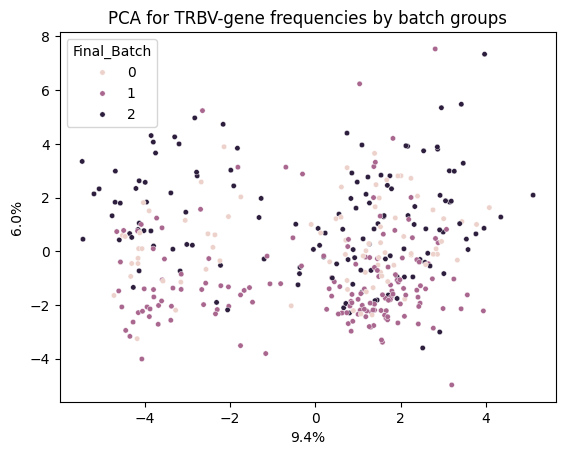

In [6]:
pca_obj = PCA(n_components=62)
principal_comps = pd.DataFrame(
    pca_obj.fit_transform(clr_V_freqs),
    columns = [f"PC{i+1}" for i in range(62)]
)
principal_comps["SRR"] = SRRs

principal_comps = principal_comps.merge(meta_subset, on="SRR", how = "inner")

sns.scatterplot(data=principal_comps,
                    x="PC1",
                    y="PC2",
                    hue="Final_Batch",
                    s=15)
plt.xlabel(f'{pca_obj.explained_variance_ratio_[0] * 100:.1f}%')
plt.ylabel(f'{pca_obj.explained_variance_ratio_[1] * 100:.1f}%')

plt.title("PCA for TRBV-gene frequencies by batch groups")
plt.show()

There is still some visible effect of batch groups on the resulting values, but data distribution demonstrates better uniformity. 

### TRBV-gene usage profiles

For the primary comparison of beta-chain V-gene usage profiles between High and Low interferon response groups across 4 diagnosis groups we used perMANOVA. If any significant difference had been found, pairwise Mann-Whitney criterion was used in order to identify genes responsible for it.

#### perMANOVA

In [8]:
clr_V_df = clr_V_freqs.reset_index().merge(meta_subset, left_on = "srr", right_on = "SRR", how = "inner")

for diagnosis in clr_V_df["diagnosis"].unique():
    subset = clr_V_df[clr_V_df["diagnosis"] == diagnosis]

    if subset["predicted_ifn_status"].nunique() < 2:
        print(f"\n=== {diagnosis}: только одна группа интерферона, пропускаем ===")
        continue
    
    dist_sub = squareform(pdist(subset[v_gene_cols], metric="euclidean"))
    dm_sub = DistanceMatrix(dist_sub, ids=subset.index)
    
    result = permanova(dm_sub, subset["predicted_ifn_status"].astype(str), permutations=999)
    print(f"\n=== diagnosis: {diagnosis} ===")
    print(result)


=== diagnosis: SLE ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     193
number of groups                  2
test statistic             1.997672
p-value                       0.003
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: H ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      59
number of groups                  2
test statistic             1.348868
p-value                       0.125
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: MS ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      63
number of groups                  2
test statistic             0.730992
p-value                       0.851
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: CLE ===
method name               PERMANOV

Some statistical significance was found for High and Low interferon response group with SLE. However, other diagnosis group did not show any significant difference in TRBV usage profiles between Low and High interferon samples. Considering this, genes that are possibly responsible for anti-interferon beta immune response were identified using pairwise Mann-Whitney criterion.

Mann-Whitney pairwise comparison results are presented below:

In [9]:
all_results = []

subset = clr_V_df[clr_V_df["diagnosis"] == "SLE"]

g1 = subset[subset["predicted_ifn_status"] == "High"]
g2 = subset[subset["predicted_ifn_status"] == "Low"]

for gene in v_gene_cols:
    stat, p = mannwhitneyu(g1[gene].values, g2[gene].values, alternative="two-sided")
    all_results.append({
        "diagnosis": "SLE",
        "gene": gene,
        "p_value": p,
        "mean_g1": g1[gene].mean(),
        "mean_g2": g2[gene].mean(),
        "group1": "High",
        "group2": "Low",
    })

results_df = pd.DataFrame(all_results)

results_df["p_adj"] = results_df.groupby("diagnosis")["p_value"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

sig = results_df[results_df["p_adj"] < 0.05].sort_values(["diagnosis", "p_adj"])
display(sig)

,diagnosis,gene,p_value,mean_g1,mean_g2,group1,group2,p_adj
47,SLE,TRBV6-4,0.000099,-0.756895,-0.191024,High,Low,0.006238
23,SLE,TRBV23-1,0.000237,-1.292771,-0.647200,High,Low,0.007453
29,SLE,TRBV29-1,0.001845,2.457543,2.728866,High,Low,0.038744


High vs. Low: Mann-Whitney-Wilcoxon test two-sided, P_val:2.816e-04 U_stat=3.242e+03
High vs. Low: Mann-Whitney-Wilcoxon test two-sided, P_val:6.805e-04 U_stat=3.334e+03


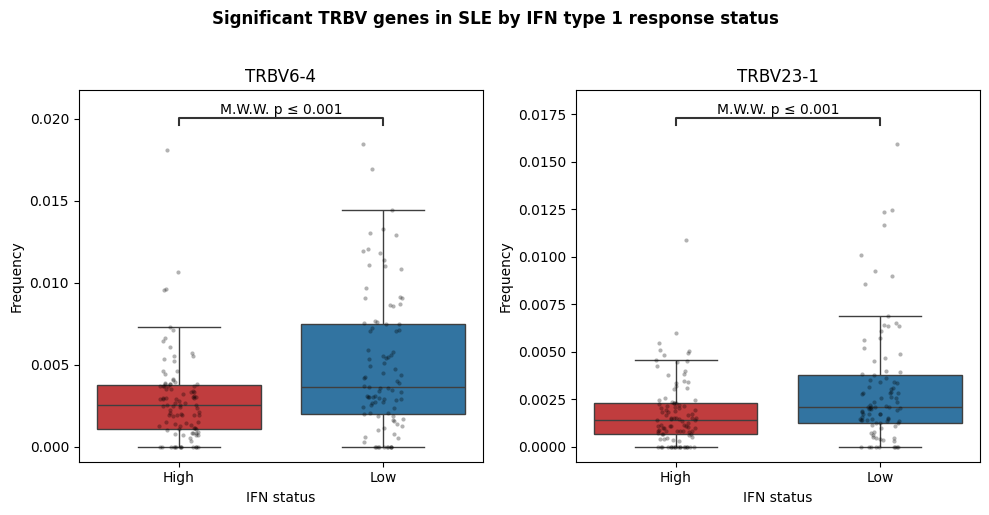

In [10]:
sig_genes = ["TRBV6-4", "TRBV23-1"]

v_freq_matrix = v_freq_matrix.reset_index().merge(meta_subset, left_on="srr", right_on="SRR", how="inner")
sle = v_freq_matrix[v_freq_matrix["diagnosis"] == "SLE"].copy()

fig, axes = plt.subplots(1, len(sig_genes), figsize=(5 * len(sig_genes), 5))

pairs = [("High", "Low")]

for ax, gene in zip(axes, sig_genes):
    sns.boxplot(data=sle,
                x="predicted_ifn_status",
                y=gene,
                ax=ax,
                order=["High", "Low"],
                hue="predicted_ifn_status",
                palette={'High': '#d62728', 'Low': '#1f77b4'},
                legend=False,
                showfliers=False)
    sns.stripplot(data=sle, x="predicted_ifn_status", y=gene, ax=ax, order=["High", "Low"],
                  color="black", alpha=0.3, size=3)

    annotator = Annotator(ax, pairs, data=sle, x="predicted_ifn_status", y=gene, order=["High", "Low"])
    annotator.configure(test="Mann-Whitney", text_format="simple", loc="inside")
    annotator.apply_and_annotate()

    ax.set_title(gene)
    ax.set_xlabel("IFN status")
    ax.set_ylabel("Frequency")

plt.suptitle("Significant TRBV genes in SLE by IFN type 1 response status", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Final visualisation of TRBV usage profiles across samples

/home/bioinf2026/losev1/miniforge3/envs/MiXCR_analysis/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


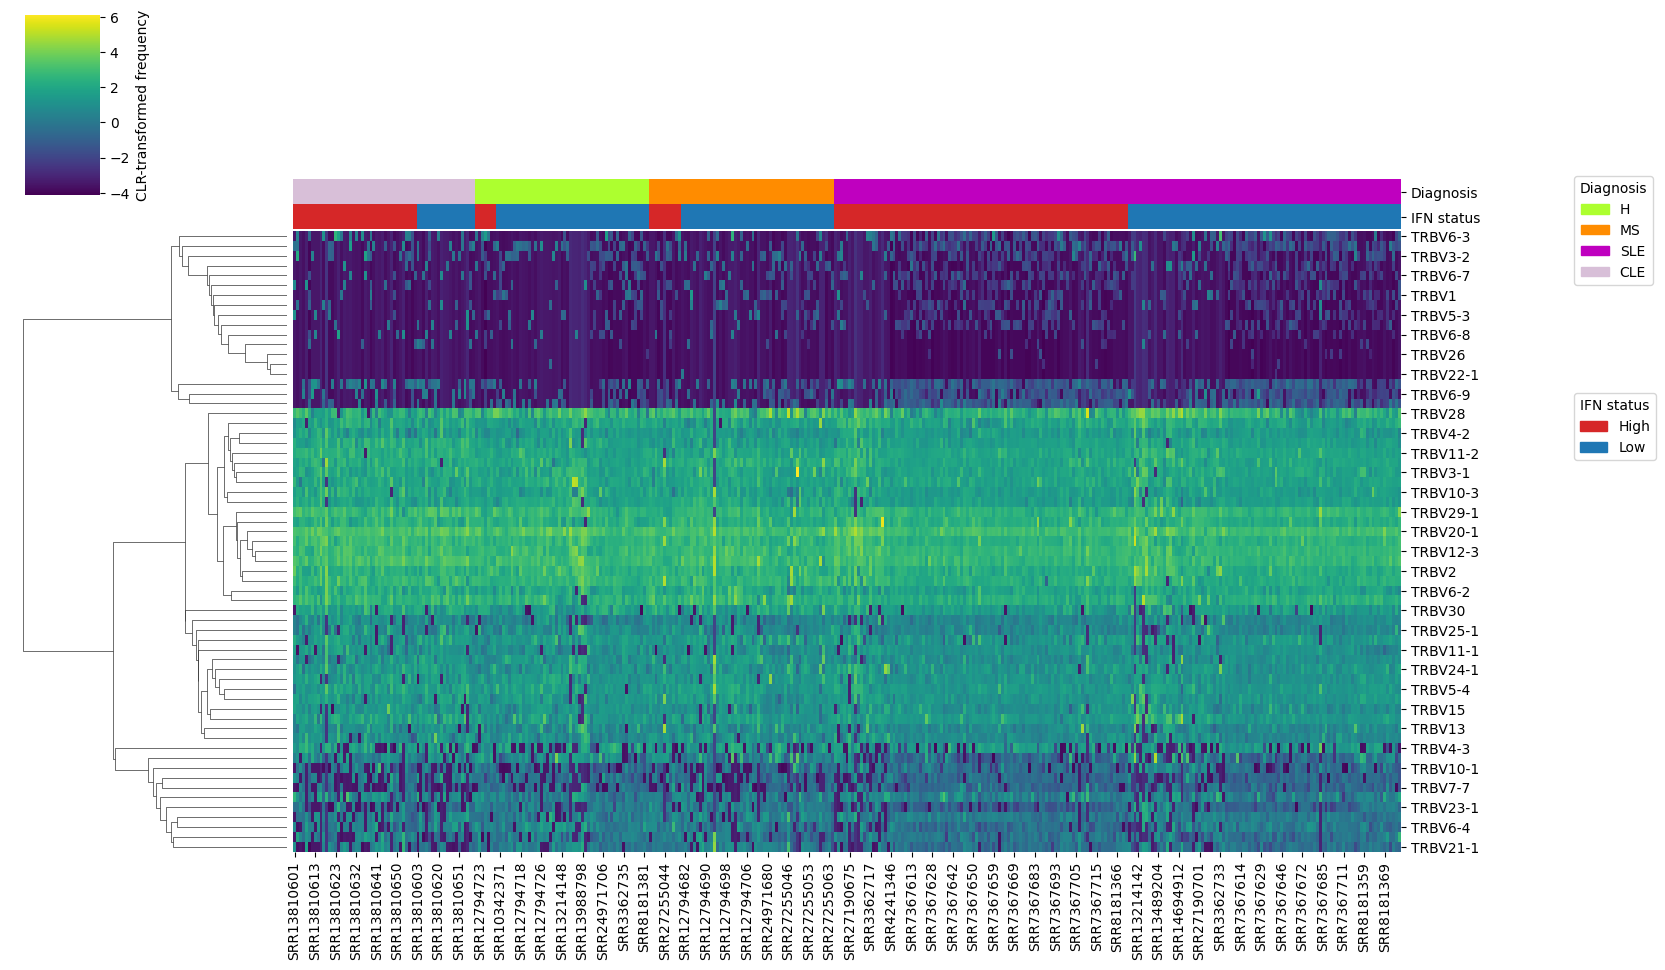

In [11]:
diagnosis_palette = {'H': 'greenyellow', 'MS': 'darkorange', 'SLE': 'm', 'CLE': 'thistle'}
ifn_palette = {"High": "#d62728", "Low": "#1f77b4"}

col_order = clr_V_df.sort_values(["diagnosis", "predicted_ifn_status"])["SRR"].values

col_colors = pd.DataFrame({
    "Diagnosis": clr_V_df.set_index("SRR").loc[col_order, "diagnosis"].map(diagnosis_palette),
    "IFN status": clr_V_df.set_index("SRR").loc[col_order, "predicted_ifn_status"].map(ifn_palette)
}, index=col_order)

data_matrix = clr_V_df.set_index("SRR")[v_gene_cols].T[col_order]

g = sns.clustermap(
    data=data_matrix,
    col_colors=col_colors,
    col_cluster=False,
    row_cluster=True,
    cmap="viridis",
    figsize=(15, 10),
    cbar_kws={"label": "CLR-transformed frequency"}
)

diag_patches = [mpatches.Patch(color=c, label=l) for l, c in diagnosis_palette.items()]
ifn_patches = [mpatches.Patch(color=c, label=l) for l, c in ifn_palette.items()]

leg1 = g.ax_heatmap.legend(
    handles=diag_patches, title="Diagnosis",
    loc="upper left", bbox_to_anchor=(1.15, 1.1),
    frameon=True
)
g.ax_heatmap.add_artist(leg1)

g.ax_heatmap.legend(
    handles=ifn_patches, title="IFN status",
    loc="upper left", bbox_to_anchor=(1.15, 0.75),
    frameon=True
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.show()

For V-segment of TCR beta chained only 2 genes have shown higher frequencies for SLE samples with Low interferon beta response. This might imply their involvement in anti-interferon beta autoimmune response, but it should be noted that the effect size is small so these 2 changes are to be regarded as potential candidates with great caution. TRBV29-1 was not included in the analysis due to the highest p-value and the lowest size effect.

For multiple sclerosis and CLE no significantly presented V-genes were found in Low interferon response samples.

## D-segment gene usage


In [14]:
d_count_matrix = utils.get_gene_count_matrix("TRB", "D", results_path, metadata).T
d_gene_cols = d_count_matrix.columns
d_count_matrix.head()

gene,TRBD1,TRBD2
srr,,
SRR10342368,189.0,60.0
SRR10342369,1999.0,953.0
SRR10342370,1402.0,1104.0
SRR10342371,897.0,503.0
SRR12794681,291.0,211.0


In [15]:
d_freq_matrix = d_count_matrix.div(d_count_matrix.sum(axis=1), axis=0)
clr_d_matrix = utils.clr_transform(d_freq_matrix)
clr_d_df = clr_d_matrix.reset_index(names="SRR").merge(meta_subset, on = "SRR")
clr_d_df


,SRR,TRBD1,TRBD2,diagnosis,Final_Batch,predicted_ifn_status,GSE
0,SRR10342368,0.573701,-0.573701,SLE,1,Low,GSE139350
1,SRR10342369,0.370394,-0.370394,SLE,1,Low,GSE139350
2,SRR10342370,0.119480,-0.119480,H,0,Low,GSE139350
3,SRR10342371,0.289233,-0.289233,H,1,Low,GSE139350
4,SRR12794681,0.160733,-0.160733,MS,2,Low,GSE159225
...,...,...,...,...,...,...,...
372,SRR8181378,0.308279,-0.308279,H,0,Low,GSE122459
373,SRR8181379,0.694519,-0.694519,H,0,Low,GSE122459
374,SRR8181380,0.305792,-0.305792,H,0,Low,GSE122459
375,SRR8181381,0.323812,-0.323812,H,0,Low,GSE122459


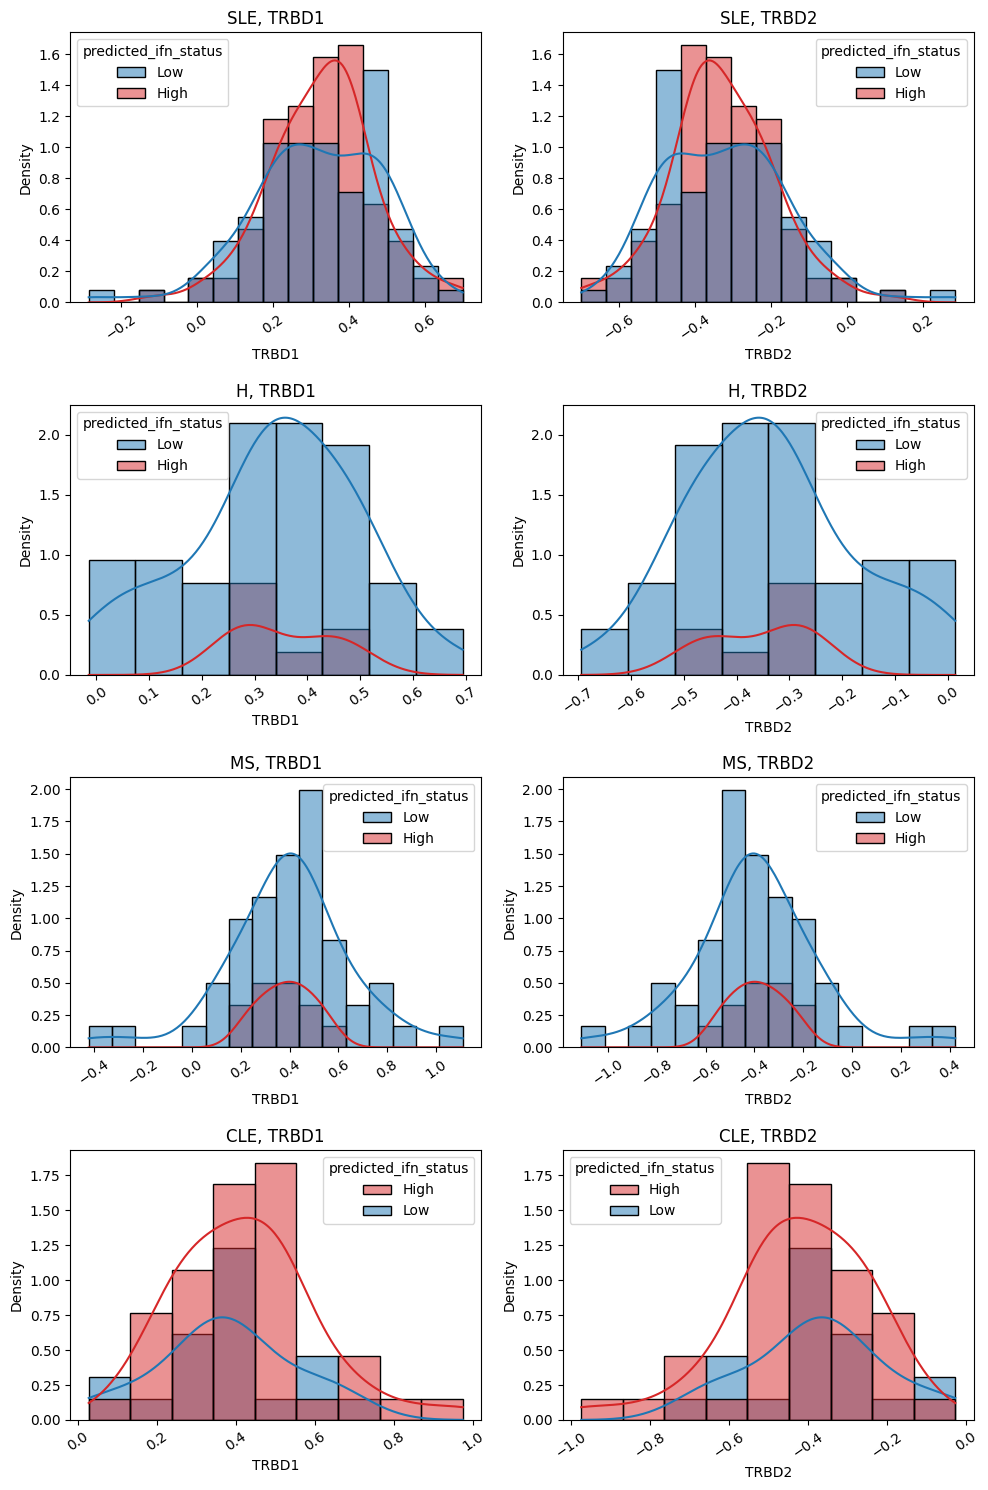

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(10, 15))

for row, diagnosis in zip(axes, clr_d_df.diagnosis.unique()):
    for ax, d_gene in zip(row, d_gene_cols):
        sns.histplot(
            data=clr_d_df[clr_d_df.diagnosis == diagnosis], 
            x=d_gene,          
            kde=True,
            hue="predicted_ifn_status",
            ax=ax,
            stat="density",     
            palette = {'High': '#d62728', 'Low': '#1f77b4'}
        )
        ax.set_title(f"{diagnosis}, {d_gene}")
        ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

# Использование V, D, J - генов бета цепи Т-клеточного рецептора

## Использование TRBV-генов

In [24]:
raw_V_counts = pd.read_csv("../results/TRBV_count_matrix.csv").set_index("v_gene")
raw_V_counts.head()

,SRR10342368,SRR10342369,SRR10342370,SRR10342371,SRR12794681,SRR12794682,SRR12794683,SRR12794684,SRR12794685,SRR12794686,...,SRR8181373,SRR8181374,SRR8181375,SRR8181376,SRR8181377,SRR8181378,SRR8181379,SRR8181380,SRR8181381,SRR8181382
v_gene,,,,,,,,,,,,,,,,,,,,,
TRBV1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,4.0,0.0,0.0
TRBV10-1,0.0,26.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,...,1.0,6.0,2.0,1.0,8.0,2.0,8.0,5.0,1.0,13.0
TRBV10-2,2.0,15.0,8.0,20.0,4.0,4.0,1.0,2.0,4.0,3.0,...,9.0,8.0,16.0,33.0,10.0,2.0,8.0,15.0,6.0,16.0
TRBV10-3,4.0,30.0,44.0,28.0,7.0,19.0,10.0,4.0,12.0,27.0,...,37.0,31.0,29.0,14.0,30.0,45.0,36.0,69.0,16.0,80.0
TRBV11-1,4.0,7.0,19.0,15.0,4.0,9.0,0.0,1.0,7.0,14.0,...,30.0,18.0,11.0,13.0,25.0,32.0,9.0,56.0,14.0,15.0


In [25]:
metadata = pd.read_csv("../data/metadata_batch_groups_with_ifn_score.csv")
metadata.head()

,Unnamed: 0,SRR,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,...,state_province,continent,ifn_status,Batch_GMM,Batch_GMM_Harmony,Batch_GMM_Harmony_k3,Final_Batch,IFN_Activity_Score,predicted_ifn_status,batch_group
0,0,SRR10342368,GSE139350,PBMC,SLE,F,47.0,NaN,polyA,NaN,...,Hubei,NaN,NaN,1,1,1,1,0.06,Low,1.0
1,1,SRR10342369,GSE139350,PBMC,SLE,F,38.0,NaN,polyA,NaN,...,Hubei,NaN,NaN,1,1,1,1,0.47,Low,1.0
2,2,SRR10342370,GSE139350,PBMC,H,F,45.0,NaN,polyA,NaN,...,Hubei,NaN,NaN,1,0,0,0,0.00,Low,1.0
3,3,SRR10342371,GSE139350,PBMC,H,F,37.0,NaN,polyA,NaN,...,Hubei,NaN,NaN,1,1,1,1,0.00,Low,1.0
4,4,SRR12794681,GSE159225,Leukocytes,MS,M,NaN,NaN,total,NaN,...,NaN,Europe,NaN,2,2,2,2,0.00,Low,2.0


### Получение матрицы частот и CLR-преобразование
Для избавления от батч-эффекта беру частоты и для поправки на композиционность делаю CLR-трансформацию

In [26]:
raw_V_freqs = raw_V_counts.div(raw_V_counts.sum(axis = 0), axis = 1)
raw_V_freqs.head(3)

,SRR10342368,SRR10342369,SRR10342370,SRR10342371,SRR12794681,SRR12794682,SRR12794683,SRR12794684,SRR12794685,SRR12794686,...,SRR8181373,SRR8181374,SRR8181375,SRR8181376,SRR8181377,SRR8181378,SRR8181379,SRR8181380,SRR8181381,SRR8181382
v_gene,,,,,,,,,,,,,,,,,,,,,
TRBV1,0.000000,0.000000,0.000305,0.000563,0.000000,0.000000,0.000000,0.010490,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000689,0.000617,0.000454,0.000000,0.002216,0.000000,0.000000
TRBV10-1,0.000000,0.007307,0.000610,0.000000,0.003096,0.000000,0.002165,0.000000,0.003953,0.001332,...,0.000654,0.005051,0.001125,0.000689,0.004932,0.000908,0.004467,0.002770,0.000666,0.004218
TRBV10-2,0.006231,0.004216,0.002439,0.011261,0.006192,0.007477,0.002165,0.006993,0.007905,0.003995,...,0.005890,0.006734,0.008999,0.022727,0.006165,0.000908,0.004467,0.008310,0.003997,0.005191


In [27]:
clr_V_freqs = raw_V_freqs.copy()
clr_V_freqs = multi_replace(clr_V_freqs)

clr_V_freqs = clr(clr_V_freqs)
clr_V_freqs = pd.DataFrame(clr_V_freqs, index=raw_V_freqs.index, columns=raw_V_freqs.columns)
clr_V_freqs.head(3)


,SRR10342368,SRR10342369,SRR10342370,SRR10342371,SRR12794681,SRR12794682,SRR12794683,SRR12794684,SRR12794685,SRR12794686,...,SRR8181373,SRR8181374,SRR8181375,SRR8181376,SRR8181377,SRR8181378,SRR8181379,SRR8181380,SRR8181381,SRR8181382
v_gene,,,,,,,,,,,,,,,,,,,,,
TRBV1,-1.659339,-1.659339,4.430153,5.043633,-1.659339,-1.659339,-1.659339,7.968372,-1.659339,-1.659339,...,-1.659339,-1.659339,-1.659339,5.245055,5.134337,4.828176,-1.659339,6.413730,-1.659339,-1.659339
TRBV10-1,-4.297115,2.501410,0.017816,-4.297115,1.642615,-4.297115,1.284703,-4.297115,1.886878,0.798862,...,0.088552,2.132000,0.630170,0.139570,2.108294,0.415839,2.009180,1.531389,0.106381,1.951883
TRBV10-2,0.752983,0.362374,-0.184880,1.344891,0.746772,0.935305,-0.304288,0.868433,0.991035,0.308484,...,0.696787,0.830692,1.120622,2.047088,0.742447,-1.173151,0.420189,1.041012,0.309150,0.570532


### Стат обработка

Сначала перманова внутри каждого диагноза, потом попарный Вилкоксон с FDR. Первостепенно добавляю лейблы.

In [28]:
clr_V_df = clr_V_freqs.T.reset_index(names="SRR")
meta_subset = metadata[["SRR", "GSE", "predicted_ifn_status", "diagnosis"]]

clr_V_df = clr_V_df.merge(meta_subset, on = "SRR", how = "inner")
clr_V_df.head(3)

,SRR,TRBV1,TRBV10-1,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-1,TRBV12-2,...,TRBV7-4,TRBV7-5,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9,GSE,predicted_ifn_status,diagnosis
0,SRR10342368,-1.659339,-4.297115,0.752983,-0.347735,0.574329,0.148804,0.253243,-1.876261,-2.052922,...,-3.467873,-0.606727,0.298862,1.991729,-0.339009,-0.705583,-0.850438,GSE139350,Low,SLE
1,SRR10342369,-1.659339,2.501410,0.362374,-0.738345,-1.271568,-0.790372,0.843462,4.080502,-2.052922,...,-3.467873,-0.606727,-0.807368,-0.413784,0.199917,-0.297685,0.587079,GSE139350,Low,SLE
2,SRR10342370,4.430153,0.017816,-0.184880,-0.273997,-0.191684,-0.611378,0.008527,-1.876261,-2.052922,...,2.481335,-0.606727,-0.558959,1.277009,-0.989190,-0.321691,-0.444567,GSE139350,Low,H


Проверка на нормальность

In [29]:
c = 0
not_normal_genes = []
gene_cols = clr_V_freqs.index

for gene in gene_cols:
    res = shapiro(clr_V_df[gene])
    if res.pvalue > 0.05:
        c += 1
    else:
        not_normal_genes.append(gene)

print(f"Out of 63 genes {c} have normal distribution")
print("Non-normal distribution is observed in:")
print(*not_normal_genes, sep=", ")

Out of 63 genes 0 have normal distribution
Non-normal distribution is observed in:
TRBV1, TRBV10-1, TRBV10-2, TRBV10-3, TRBV11-1, TRBV11-2, TRBV11-3, TRBV12-1, TRBV12-2, TRBV12-3, TRBV12-4, TRBV12-5, TRBV13, TRBV14, TRBV15, TRBV16, TRBV17, TRBV18, TRBV19, TRBV2, TRBV20-1, TRBV21-1, TRBV22-1, TRBV23-1, TRBV24-1, TRBV25-1, TRBV26, TRBV27, TRBV28, TRBV29-1, TRBV3-1, TRBV3-2, TRBV30, TRBV4-1, TRBV4-2, TRBV4-3, TRBV5-1, TRBV5-2, TRBV5-3, TRBV5-4, TRBV5-5, TRBV5-6, TRBV5-7, TRBV5-8, TRBV6-1, TRBV6-2, TRBV6-3, TRBV6-4, TRBV6-5, TRBV6-6, TRBV6-7, TRBV6-8, TRBV6-9, TRBV7-1, TRBV7-2, TRBV7-3, TRBV7-4, TRBV7-5, TRBV7-6, TRBV7-7, TRBV7-8, TRBV7-9, TRBV9


Ничего не нормально, перманова

In [30]:
# матрица расстояний
dist_matrix = squareform(pdist(clr_V_df[gene_cols], metric="euclidean"))
dm = DistanceMatrix(dist_matrix, ids=clr_V_df.index)

# тестируем каждый фактор отдельно
result_diagnosis = permanova(dm, clr_V_df["diagnosis"].astype(str), permutations=999)
result_ifn = permanova(dm, clr_V_df["predicted_ifn_status"].astype(str), permutations=999)

print("=== diagnosis ===")
print(result_diagnosis)
print("\n=== interferon ===")
print(result_ifn)

=== diagnosis ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     377
number of groups                  4
test statistic             7.441994
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

=== interferon ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     377
number of groups                  2
test statistic             3.039584
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


In [31]:
for diagnosis in clr_V_df["diagnosis"].unique():
    subset = clr_V_df[clr_V_df["diagnosis"] == diagnosis]
    
    # пропускаем если только одна группа интерферона
    if subset["predicted_ifn_status"].nunique() < 2:
        print(f"\n=== {diagnosis}: только одна группа интерферона, пропускаем ===")
        continue
    
    dist_sub = squareform(pdist(subset[gene_cols], metric="euclidean"))
    dm_sub = DistanceMatrix(dist_sub, ids=subset.index)
    
    result = permanova(dm_sub, subset["predicted_ifn_status"].astype(str), permutations=999)
    print(f"\n=== diagnosis: {diagnosis} ===")
    print(result)

KeyboardInterrupt: 

In [ ]:
all_results = []

for diagnosis in clr_V_df["diagnosis"].unique():
    subset = clr_V_df[clr_V_df["diagnosis"] == diagnosis]
    
    ifn_groups = subset["predicted_ifn_status"].unique()
    if len(ifn_groups) < 2:
        continue
    
    g1 = subset[subset["predicted_ifn_status"] == ifn_groups[0]]
    g2 = subset[subset["predicted_ifn_status"] == ifn_groups[1]]
    
    for gene in gene_cols:
        stat, p = mannwhitneyu(g1[gene].values, g2[gene].values, alternative="two-sided")
        all_results.append({
            "diagnosis": diagnosis,
            "gene": gene,
            "p_value": p,
            "mean_g1": g1[gene].mean(),
            "mean_g2": g2[gene].mean(),
            "group1": ifn_groups[0],
            "group2": ifn_groups[1],
        })

results_df = pd.DataFrame(all_results)

results_df["p_adj"] = results_df.groupby("diagnosis")["p_value"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

sig = results_df[results_df["p_adj"] < 0.05].sort_values(["diagnosis", "p_adj"])
display(sig)

,diagnosis,gene,p_value,mean_g1,mean_g2,group1,group2,p_adj
23,SLE,TRBV23-1,0.000681,0.473795,-0.318029,Low,High,0.014291
27,SLE,TRBV27,0.000673,0.005543,0.213703,Low,High,0.014291
47,SLE,TRBV6-4,0.000282,0.209502,-0.347404,Low,High,0.014291
4,SLE,TRBV11-1,0.003134,0.005406,0.386381,Low,High,0.049363


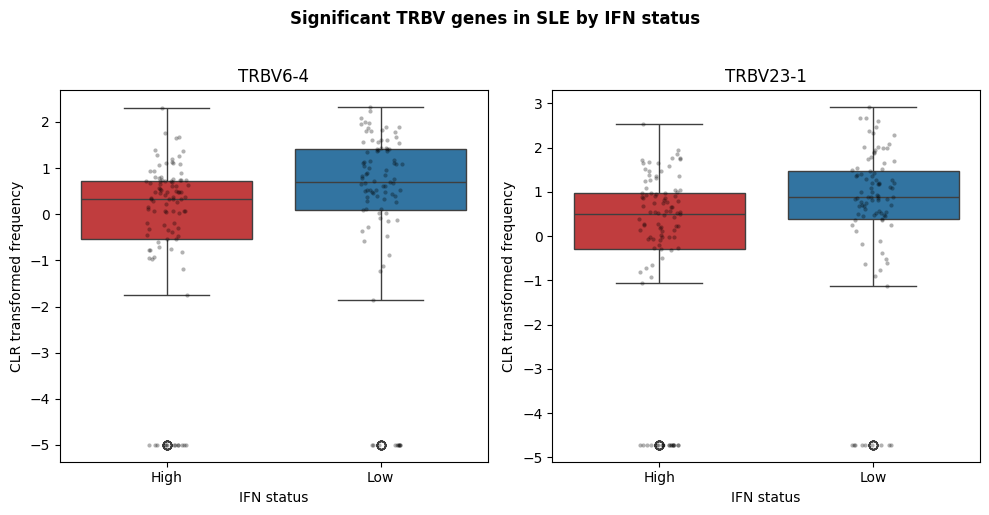

In [ ]:
sig_genes = sig[(sig.p_adj < 0.05) & (sig.diagnosis != "H")]["gene"]
sig_genes = ["TRBV6-4", "TRBV23-1"]
sle = clr_V_df[clr_V_df["diagnosis"] == "SLE"]

fig, axes = plt.subplots(1, len(sig_genes), figsize=(5 * len(sig_genes), 5))

for ax, gene in zip(axes, sig_genes):
    sns.boxplot(data=sle,
                x="predicted_ifn_status",
                y=gene,
                ax=ax,
                order=["High", "Low"],
                hue = "predicted_ifn_status",
                palette = {'High': '#d62728', 'Low': '#1f77b4'},
                legend=False)
    sns.stripplot(data=sle, x="predicted_ifn_status", y=gene, ax=ax, order=["High", "Low"],
                  color="black", alpha=0.3, size=3)
    ax.set_title(gene)
    ax.set_xlabel("IFN status")
    ax.set_ylabel("CLR transformed frequency")

plt.suptitle("Significant TRBV genes in SLE by IFN status", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Теперь посмотрим, какие варианты этих генов с кем чаще образуют комбинации, 

Для этого будем получать матрицы частот комбинаций для каждого гена.

In [ ]:
vj_records = []  # список для накопления записей

for file in files["TRB"]:
    report = pd.read_csv(file, sep="\t")
    
    # Удаляем нефункциональные клоны
    report = report[~report.aaSeqCDR3.str.contains(r"[_*]", na=False)]
    
    # Получаем SRR из имени файла
    srr = os.path.basename(file).split(".")[0]
    
    # Фильтруем по V генам
    # report_subset = report[report.allVHitsWithScore.str.contains(r"^(TRBV23-1|TRBV6-4)", na=False)]
    
    # Если после фильтрации есть данные
    if len(report) > 0:
        # Добавляем каждую строку как отдельную запись
        for idx, row in report.iterrows():
            vj_records.append({
                "SRR": srr,
                "v_gene": row.allVHitsWithScore.split("(")[0] if pd.notna(row.allVHitsWithScore) else pd.NA,
                "j_gene": row.allJHitsWithScore.split("(")[0] if pd.notna(row.allJHitsWithScore) else pd.NA,
                "readCount": row.readCount
            })



NameError: name 'files' is not defined

In [ ]:
# Создаем итоговый DataFrame
vj_df = pd.DataFrame(vdj_records)

In [ ]:
vdj_df

,SRR,v_gene,d_gene,j_gene,readCount
0,SRR13810613,TRBV7-8*00,TRBD1*00,TRBJ1-5*00,4.0
1,SRR13810613,TRBV6-5*00,TRBD1*00,TRBJ1-1*00,3.0
2,SRR13810613,TRBV6-6*00,TRBD1*00,TRBJ1-2*00,3.0
3,SRR13810613,TRBV7-9*00,NaN,TRBJ1-5*00,3.0
4,SRR13810613,TRBV7-9*00,NaN,TRBJ1-1*00,3.0
...,...,...,...,...,...
537523,SRR7367748,TRBV20-1*00,NaN,TRBJ1-1*00,1.0
537524,SRR7367748,TRBV29-1*00,NaN,TRBJ1-1*00,1.0
537525,SRR7367748,TRBV7-3*00,NaN,TRBJ2-1*00,1.0
537526,SRR7367748,TRBV7-4*00,NaN,TRBJ1-4*00,1.0


In [ ]:
def make_vj_matrix(df):
    # df columns: sample_id, v_gene, j_gene, cloneCount
    vj = df.copy().fillna('_')

    vj = (df
          .groupby(['SRR', 'v_gene', 'j_gene'])['readCount']
          .sum()
          .reset_index())
    
    vj['vj'] = vj['v_gene'] + "_" + vj['j_gene']
    
    # каунт матрица
    counts = vj.pivot_table(
        index='SRR',
        columns='vj',
        values='readCount',
        fill_value=0
    )
    
    # частоты внутри образца
    freqs = counts.div(counts.sum(axis=1), axis=0)
    
    return counts, freqs

counts_vj, freqs_vj = make_vj_matrix(vdj_df)

In [ ]:
# Фильтруем колонки напрямую (если V-ген в начале имени колонки)
vj_cols_of_interest = [col for col in freqs_vj.columns if col.startswith("TRBV6-4")]
freqs_v6 = freqs_vj[vj_cols_of_interest]
freqs_v6

vj,TRBV6-4*00_TRBJ1-1*00,TRBV6-4*00_TRBJ1-2*00,TRBV6-4*00_TRBJ1-3*00,TRBV6-4*00_TRBJ1-4*00,TRBV6-4*00_TRBJ1-5*00,TRBV6-4*00_TRBJ1-6*00,TRBV6-4*00_TRBJ2-1*00,TRBV6-4*00_TRBJ2-2*00,TRBV6-4*00_TRBJ2-3*00,TRBV6-4*00_TRBJ2-4*00,TRBV6-4*00_TRBJ2-5*00,TRBV6-4*00_TRBJ2-6*00,TRBV6-4*00_TRBJ2-7*00
SRR,,,,,,,,,,,,,
SRR10342368,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
SRR10342369,0.000162,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
SRR10342370,0.000915,0.000000,0.0,0.0,0.000000,0.0,0.000610,0.000000,0.000305,0.0,0.000000,0.0,0.000000
SRR10342371,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.001689,0.000000,0.002815,0.0,0.000000,0.0,0.000000
SRR12794681,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.001548,0.000000,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR8181378,0.000454,0.000000,0.0,0.0,0.000454,0.0,0.001362,0.000454,0.003177,0.0,0.000000,0.0,0.000454
SRR8181379,0.004467,0.000000,0.0,0.0,0.000000,0.0,0.001117,0.000558,0.001675,0.0,0.000000,0.0,0.000558
SRR8181380,0.000554,0.000000,0.0,0.0,0.000000,0.0,0.000554,0.000554,0.000000,0.0,0.000554,0.0,0.000554


In [ ]:
# Разбираем VDJ комбинацию на составляющие
freqs_v6_long = (freqs_v6
    .reset_index()
    .melt(id_vars='SRR', var_name='vj_combination', value_name='frequency')
    .dropna(subset=['frequency'])
)

# Извлекаем J гены
freqs_v6_long['j_gene'] = freqs_v6_long['vj_combination'].str.split('_').str[1]

freqs_v6_long = freqs_v6_long.merge(meta_subset, on="SRR", how = "inner")

In [ ]:
freqs_v6_long[(freqs_v6_long['predicted_ifn_status'] == "Low") & (freqs_v6_long.frequency != 0) & (freqs_v6_long.diagnosis == "SLE")]["j_gene"].value_counts()

j_gene
TRBJ2-1*00    61
TRBJ2-3*00    60
TRBJ1-1*00    46
TRBJ2-2*00    46
TRBJ2-7*00    35
TRBJ1-2*00    33
TRBJ1-5*00    31
TRBJ2-5*00    19
TRBJ1-6*00    18
TRBJ2-6*00    11
TRBJ1-4*00     9
TRBJ1-3*00     5
TRBJ2-4*00     5
Name: count, dtype: int64

In [ ]:
freqs_v6_long[(freqs_v6_long['predicted_ifn_status'] == "High") & (freqs_v6_long.frequency != 0) & (freqs_v6_long.diagnosis == "SLE")]["j_gene"].value_counts()

j_gene
TRBJ2-1*00    59
TRBJ1-1*00    49
TRBJ2-3*00    49
TRBJ2-7*00    42
TRBJ1-2*00    33
TRBJ1-5*00    31
TRBJ2-2*00    31
TRBJ1-6*00    15
TRBJ2-6*00    15
TRBJ2-5*00    14
TRBJ1-4*00    10
TRBJ1-3*00     7
TRBJ2-4*00     5
Name: count, dtype: int64

In [ ]:
freqs_v6_long[(freqs_v6_long['predicted_ifn_status'] == "Low") & (freqs_v6_long.frequency != 0) & (freqs_v6_long.diagnosis == "SLE")]["j_gene"].value_counts()

j_gene
TRBJ2-1*00    61
TRBJ2-3*00    60
TRBJ1-1*00    46
TRBJ2-2*00    46
TRBJ2-7*00    35
TRBJ1-2*00    33
TRBJ1-5*00    31
TRBJ2-5*00    19
TRBJ1-6*00    18
TRBJ2-6*00    11
TRBJ1-4*00     9
TRBJ1-3*00     5
TRBJ2-4*00     5
Name: count, dtype: int64

In [ ]:
freqs_v6_long[(freqs_v6_long['predicted_ifn_status'] == "High") & (freqs_v6_long.frequency != 0) & (freqs_v6_long.diagnosis == "SLE")]["j_gene"].value_counts()

j_gene
TRBJ2-1*00    59
TRBJ1-1*00    49
TRBJ2-3*00    49
TRBJ2-7*00    42
TRBJ1-2*00    33
TRBJ1-5*00    31
TRBJ2-2*00    31
TRBJ1-6*00    15
TRBJ2-6*00    15
TRBJ2-5*00    14
TRBJ1-4*00    10
TRBJ1-3*00     7
TRBJ2-4*00     5
Name: count, dtype: int64

/home/bioinf2026/losev1/miniforge3/envs/MiXCR_analysis/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


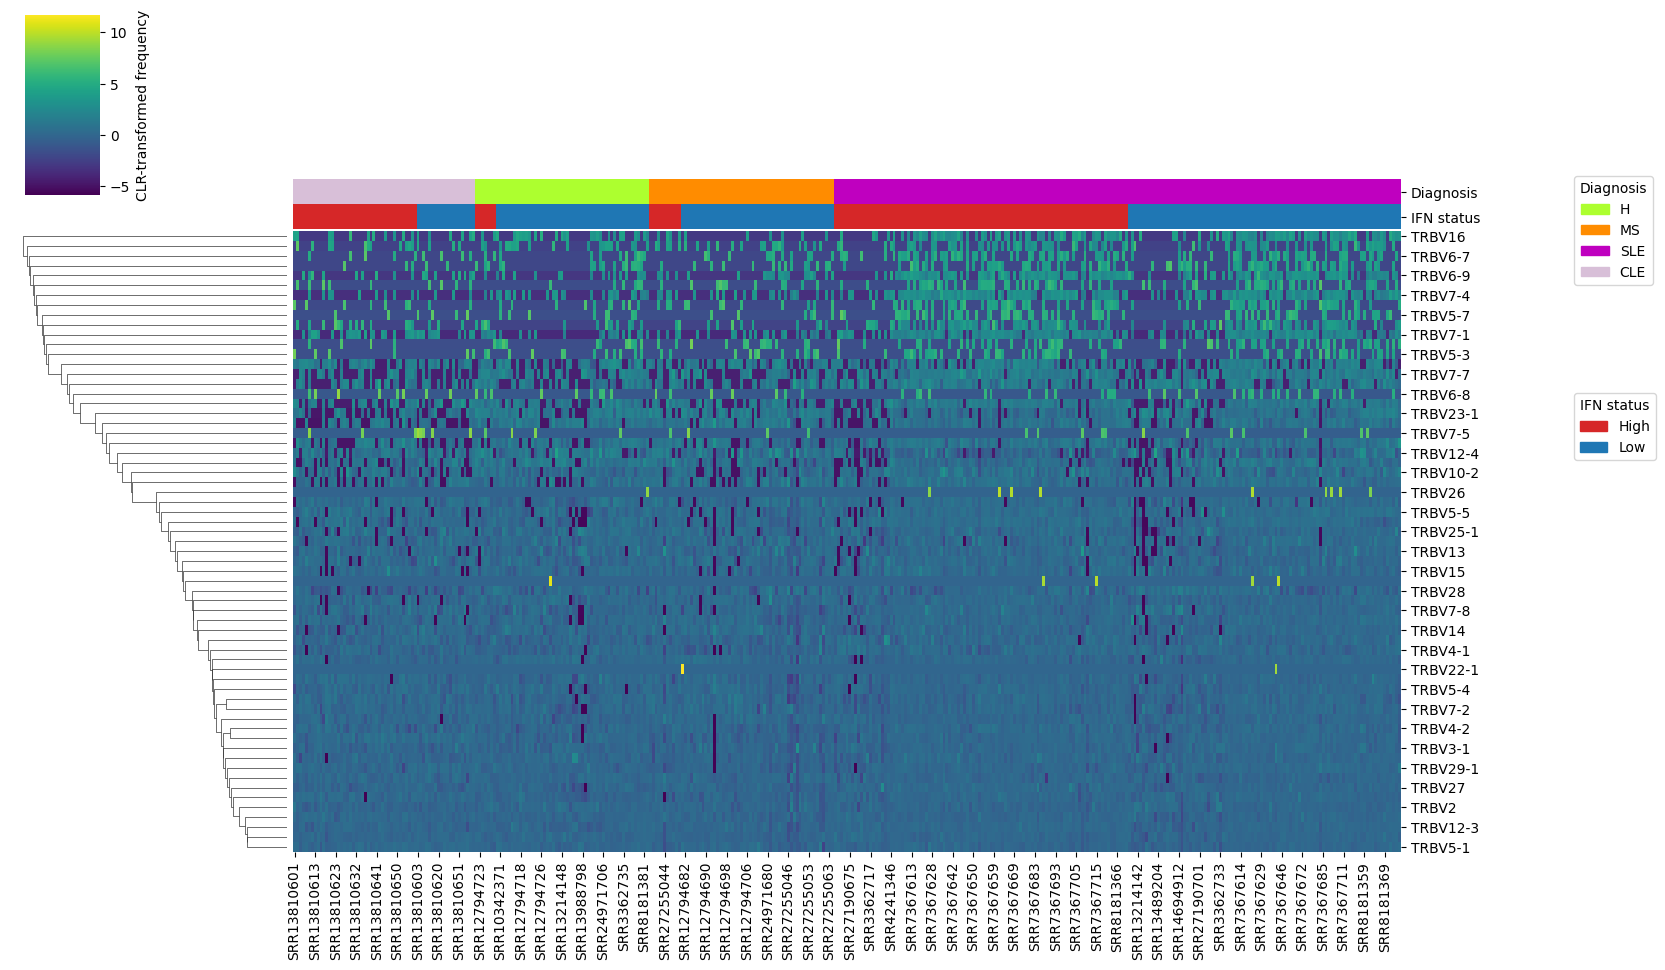

In [ ]:
import matplotlib.patches as mpatches

diagnosis_palette = {'H': 'greenyellow', 'MS': 'darkorange', 'SLE': 'm', 'CLE': 'thistle'}
ifn_palette = {"High": "#d62728", "Low": "#1f77b4"}

col_order = clr_V_df.sort_values(["diagnosis", "predicted_ifn_status"])["SRR"].values

# Строим col_colors с индексом = col_order, без лишних строк
col_colors = pd.DataFrame({
    "Diagnosis": clr_V_df.set_index("SRR").loc[col_order, "diagnosis"].map(diagnosis_palette),
    "IFN status": clr_V_df.set_index("SRR").loc[col_order, "predicted_ifn_status"].map(ifn_palette)
}, index=col_order)

data_matrix = clr_V_df.set_index("SRR")[gene_cols].T[col_order]

g = sns.clustermap(
    data=data_matrix,
    col_colors=col_colors,
    col_cluster=False,
    row_cluster=True,
    cmap="viridis",
    figsize=(15, 10),
    cbar_kws={"label": "CLR-transformed frequency"}
)

# Легенды
diag_patches = [mpatches.Patch(color=c, label=l) for l, c in diagnosis_palette.items()]
ifn_patches = [mpatches.Patch(color=c, label=l) for l, c in ifn_palette.items()]

leg1 = g.ax_heatmap.legend(
    handles=diag_patches, title="Diagnosis",
    loc="upper left", bbox_to_anchor=(1.15, 1.1),
    frameon=True
)
g.ax_heatmap.add_artist(leg1)

g.ax_heatmap.legend(
    handles=ifn_patches, title="IFN status",
    loc="upper left", bbox_to_anchor=(1.15, 0.75),
    frameon=True
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.show()